# Data Preprocessing, Model Training, and Grad-CAM

## Resize image and mask shape

In [1]:
# load libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd
import torch
from preprocess_utils import *
from CarDDCropDataset import *
import time
from datetime import datetime
import torch.nn.functional as F

In [2]:
PROJECT_DIR = Path("/Users/minkhant/Downloads/Grad-CAM_CarDD/")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "processed/padding_25pct_per_side"

samples_df = pd.read_csv(OUTPUT_DIR / "sample_manifest.csv")

with (OUTPUT_DIR / "class_to_idx.json").open() as f:
    class_to_idx = json.load(f)
    
#Restore the exact class order used during prepartion
CLASS_NAMES = [
    name
    for name, index in sorted(
        class_to_idx.items(),
        key=lambda item: item[1],
    )
]
samples_df.head()

,sample_id,split,image_id,annotation_id,source_path,category_id,category,class_index,padding_fraction_per_side,left,top,right,bottom,crop_width,crop_height
0,train_img1_ann1,train,1,1,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,2,scratch,1,0.25,116,7,421,205,305,198
1,train_img1_ann2,train,1,2,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,0,0,1000,750,1000,750
2,train_img2_ann3,train,2,3,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,377,154,974,667,597,513
3,train_img3_ann4,train,3,4,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,192,0,1000,652,808,652
4,train_img4_ann5,train,4,5,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,0,0,1000,667,1000,667


In [3]:
CROP_PADDING = max(samples_df["padding_fraction_per_side"])

SPLIT_FOLDERS = {
    "train": "train2017",
    "val": "val2017",
    "test": "test2017",
}

annotations = {}

for split, folder in SPLIT_FOLDERS.items():
    annotation_path = (
        DATA_DIR / "annotations" / f"instances_{folder}.json"
    )

    with annotation_path.open() as f:
        annotations[split] = json.load(f)

,class_index,training_crops,percentage
category,,,
dent,0,1806,29.08
scratch,1,2560,41.22
crack,2,651,10.48
glass shatter,3,475,7.65
lamp broken,4,494,7.95
tire flat,5,225,3.62


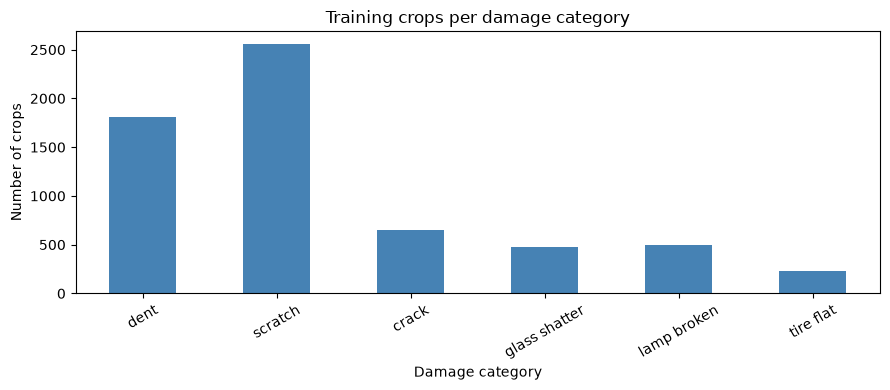

Largest-to-smallest class ratio: 11.38:1


In [4]:
train_samples = samples_df[
    samples_df["split"] == "train"
].copy()

class_counts = (
    train_samples["category"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

balance_df = pd.DataFrame({
    "class_index": [class_to_idx[name] for name in CLASS_NAMES],
    "training_crops": class_counts.to_numpy(),
    "percentage": (
        100 * class_counts / class_counts.sum()
    ).round(2).to_numpy(),
}, index=CLASS_NAMES)

balance_df.index.name = "category"
display(balance_df)

ax = class_counts.plot.bar(
    figsize=(9, 4),
    color="steelblue",
    rot=30,
)

ax.set_title("Training crops per damage category")
ax.set_xlabel("Damage category")
ax.set_ylabel("Number of crops")

plt.tight_layout()
plt.show()

if (class_counts == 0).any():
    print("WARNING: At least one category has no training samples.")
else:
    ratio = class_counts.max() / class_counts.min()
    print(f"Largest-to-smallest class ratio: {ratio:.2f}:1")

### Class Weight

In [5]:
if (class_counts == 0).any():
    raise ValueError(
        "Cannot calculate weights with an empty training category."
    )

# Weight for class c = total samples / (number of classes × class count).
# CLASS_NAMES preserves the same order as class_to_idx.
counts_tensor = torch.tensor(
    class_counts.to_numpy(),
    dtype=torch.float32,
)

class_weights = (
    counts_tensor.sum()
    / (len(CLASS_NAMES) * counts_tensor)
)

balance_df["optional_loss_weight"] = class_weights.numpy()
display(balance_df)

# Baseline:
baseline_loss = torch.nn.CrossEntropyLoss()

# Optional comparison experiment:
weighted_loss = torch.nn.CrossEntropyLoss(weight=class_weights)

,class_index,training_crops,percentage,optional_loss_weight
category,,,,
dent,0,1806,29.08,0.573182
scratch,1,2560,41.22,0.404362
crack,2,651,10.48,1.590118
glass shatter,3,475,7.65,2.179298
lamp broken,4,494,7.95,2.095479
tire flat,5,225,3.62,4.600741


Load Dataset for training

In [6]:
# Seed once before training, not inside __getitem__.
random.seed(42)
torch.manual_seed(42)

train_dataset = CarDDCropDataset(
    samples_df, annotations, "train"
)
val_dataset = CarDDCropDataset(
    samples_df, annotations, "val"
)
test_dataset = CarDDCropDataset(
    samples_df, annotations, "test"
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(42),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

creating index...
index created!
creating index...
index created!
creating index...
index created!
Training samples: 6211
Validation samples: 1744
Test samples: 785


In [7]:
batch = next(iter(train_loader))

print("Images:", batch["image"].shape)
print("Labels:", batch["label"].shape)
print("Masks:", batch["mask"].shape)

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Masks: torch.Size([16, 224, 224])


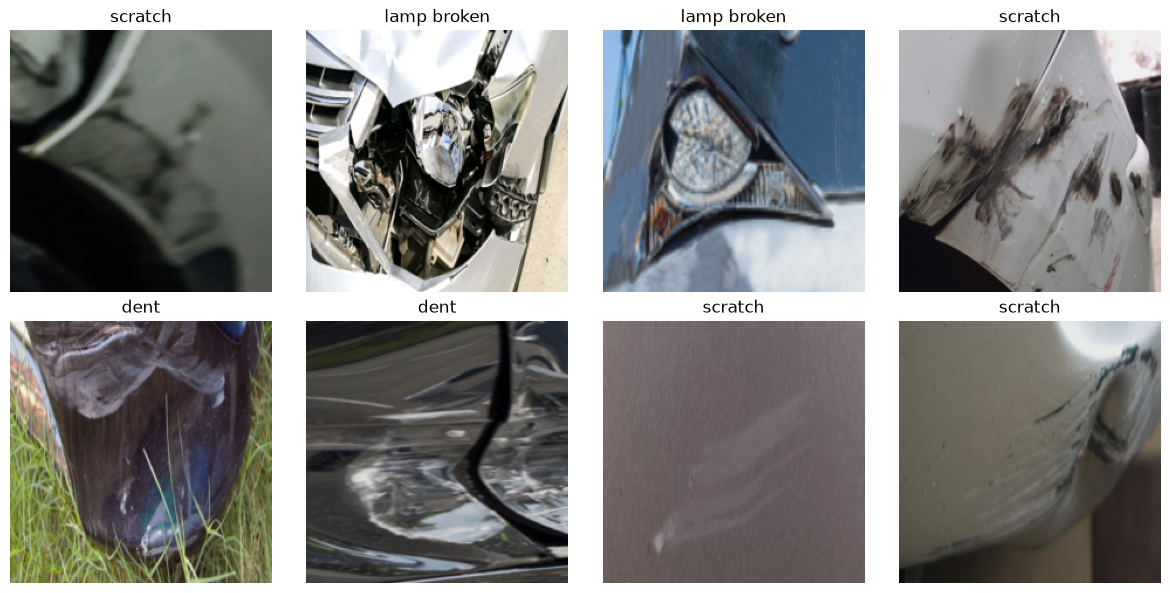

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for index, ax in enumerate(axes.flat):
    ax.axis("off")

    if index >= len(batch["image"]):
        continue

    # Undo normalization for display only.
    image = (
        batch["image"][index] * IMAGENET_STD + IMAGENET_MEAN
    ).permute(1, 2, 0).numpy().clip(0, 1)

    class_index = batch["label"][index].item()

    ax.imshow(image)
    ax.set_title(CLASS_NAMES[class_index])

plt.tight_layout()
plt.show()

### Load ResNet50

In [9]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Supported Apple GPUs
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [10]:
torch.manual_seed(42)

# Specify the weights explicitly for reproducibility.
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Initially freeze the pretrained parameters.
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the original classifier with a new, trainable layer.
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(CLASS_NAMES))

model = model.to(device)

print("New classification layer:", model.fc)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
print(f"Trainable parameters: {trainable_parameters:,}")

New classification layer: Linear(in_features=2048, out_features=6, bias=True)
Trainable parameters: 12,294


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3,
)

In [12]:
images = batch["image"].to(device)
labels = batch["label"].to(device)

model.eval()

with torch.no_grad():
    logits = model(images)
    loss = criterion(logits, labels)

logits.shape

torch.Size([16, 6])

In [13]:
def run_epoch(loader, training=False):
    # Keep the frozen backbone and its BatchNorm statistics fixed.
    model.eval()
    model.fc.train(training)

    total_loss = 0.0
    total_samples = 0
    num_classes = len(CLASS_NAMES)

    confusion = torch.zeros(
        (num_classes, num_classes), dtype=torch.long
    )

    with torch.set_grad_enabled(training):
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            if training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite loss encountered.")

            if training:
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            predictions = logits.argmax(dim=1)

            # Rows = true labels; columns = predicted labels.
            indices = (
                labels.detach().cpu() * num_classes
                + predictions.detach().cpu()
            )
            confusion += torch.bincount(
                indices, minlength=num_classes ** 2
            ).reshape(num_classes, num_classes)

    if total_samples == 0:
        raise ValueError("The data loader is empty.")

    cm = confusion.float()
    true_positives = cm.diag()

    precision = true_positives / cm.sum(dim=0).clamp(min=1)
    recall = true_positives / cm.sum(dim=1).clamp(min=1)
    f1 = (
        2 * precision * recall
        / (precision + recall).clamp(min=1e-12)
    )

    return {
        "loss": total_loss / total_samples,
        "accuracy": true_positives.sum().item() / total_samples,
        "macro_f1": f1.mean().item(),
        "per_class_f1": f1.tolist(),
    }

## Head Training

In [14]:
EPOCHS = 5

# Each run gets its own folder to preserve earlier results.
run_name = datetime.now().strftime("head_training_%Y%m%d_%H%M%S_%f")
run_dir = PROJECT_DIR / "runs" / run_name
run_dir.mkdir(parents=True, exist_ok=False)

best_checkpoint_path = run_dir / "best_head.pt"
best_val_f1 = -1.0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.perf_counter()
    print(f"Starting epoch {epoch}/{EPOCHS}...", flush=True)

    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(val_loader, training=False)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "seconds": time.perf_counter() - start,
    }
    history.append(row)

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]

        torch.save({
            "model_state_dict": {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            },
            "epoch": epoch,
            "val_macro_f1": best_val_f1,
            "class_to_idx": dict(class_to_idx),
            "weights_name": "DEFAULT",
            "target_size": list(TARGET_SIZE),
            "stage": "classifier_head_only",
        }, best_checkpoint_path)

    # Save progress after every completed epoch.
    pd.DataFrame(history).to_csv(
        run_dir / "history.csv", index=False
    )

    print(
        f"Train loss: {row['train_loss']:.4f} | "
        f"Val loss: {row['val_loss']:.4f} | "
        f"Val accuracy: {row['val_accuracy']:.3f} | "
        f"Val macro F1: {row['val_macro_f1']:.3f} | "
        f"{row['seconds']:.0f}s",
        flush=True,
    )

print("\nBest validation macro F1:", round(best_val_f1, 4))
print("Checkpoint saved to:", best_checkpoint_path)

Starting epoch 1/5...
Train loss: 0.6874 | Val loss: 0.5034 | Val accuracy: 0.816 | Val macro F1: 0.849 | 124s
Starting epoch 2/5...
Train loss: 0.4425 | Val loss: 0.4546 | Val accuracy: 0.829 | Val macro F1: 0.868 | 123s
Starting epoch 3/5...
Train loss: 0.3854 | Val loss: 0.4467 | Val accuracy: 0.828 | Val macro F1: 0.867 | 126s
Starting epoch 4/5...
Train loss: 0.3476 | Val loss: 0.4293 | Val accuracy: 0.834 | Val macro F1: 0.874 | 126s
Starting epoch 5/5...
Train loss: 0.3256 | Val loss: 0.4241 | Val accuracy: 0.830 | Val macro F1: 0.873 | 126s

Best validation macro F1: 0.8741
Checkpoint saved to: /Users/minkhant/Downloads/Grad-CAM_CarDD/runs/head_training_20260929_195354_553878/best_head.pt


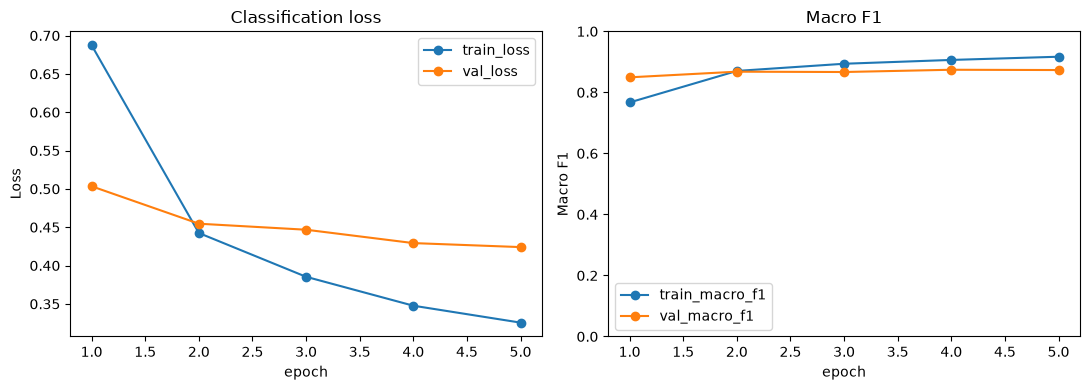

In [15]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

history_df.plot(
    x="epoch",
    y=["train_loss", "val_loss"],
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Classification loss")
axes[0].set_ylabel("Loss")

history_df.plot(
    x="epoch",
    y=["train_macro_f1", "val_macro_f1"],
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Macro F1")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
# Reload the best model from the previous stage.
checkpoint = torch.load(
    best_checkpoint_path,
    map_location="cpu",
    weights_only=True,
)

assert checkpoint["class_to_idx"] == class_to_idx

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

# Freeze everything, then unfreeze layer4 and the classifier.
for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True

criterion = nn.CrossEntropyLoss()

# A lower learning rate protects the pretrained features.
optimizer = torch.optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ]
)

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

Trainable parameters: 14,977,030


## Finetuning

In [17]:
finetune_dir = PROJECT_DIR / "runs" / datetime.now().strftime(
    "finetune_%Y%m%d_%H%M%S_%f"
)
finetune_dir.mkdir(parents=True, exist_ok=False)

finetune_checkpoint_path = finetune_dir / "best_model.pt"

starting_metrics = run_epoch(val_loader, training=False)
best_val_f1 = starting_metrics["macro_f1"]

def save_finetune_checkpoint(epoch, score):
    torch.save({
        "model_state_dict": {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        },
        "epoch": epoch,
        "val_macro_f1": score,
        "class_to_idx": dict(class_to_idx),
        "weights_name": "IMAGENET1K_V2",
        "target_size": list(TARGET_SIZE),
        "stage": (
            "head_checkpoint_before_finetuning"
            if epoch == 0 else "layer4_and_head_finetuning"
        ),
        "batchnorm_statistics": "fixed",
    }, finetune_checkpoint_path)

save_finetune_checkpoint(epoch=0, score=best_val_f1)

print("Starting validation macro F1:", round(best_val_f1, 4))

Starting validation macro F1: 0.8741


In [18]:
MAX_EPOCHS = 10
PATIENCE = 3

epochs_without_improvement = 0
finetune_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.perf_counter()
    print(f"Fine-tuning epoch {epoch}/{MAX_EPOCHS}...", flush=True)

    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(val_loader, training=False)

    finetune_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "seconds": time.perf_counter() - start,
    })

    improved = val_metrics["macro_f1"] > best_val_f1

    if improved:
        best_val_f1 = val_metrics["macro_f1"]
        epochs_without_improvement = 0
        save_finetune_checkpoint(epoch, best_val_f1)
    else:
        epochs_without_improvement += 1

    pd.DataFrame(finetune_history).to_csv(
        finetune_dir / "history.csv",
        index=False,
    )

    print(
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Val loss: {val_metrics['loss']:.4f} | "
        f"Val accuracy: {val_metrics['accuracy']:.3f} | "
        f"Val macro F1: {val_metrics['macro_f1']:.3f}"
        + (" | Saved best model" if improved else ""),
        flush=True,
    )

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping: validation macro F1 stopped improving.")
        break

print("\nBest checkpoint:", finetune_checkpoint_path)

Fine-tuning epoch 1/10...
Train loss: 0.2940 | Val loss: 0.3799 | Val accuracy: 0.854 | Val macro F1: 0.893 | Saved best model
Fine-tuning epoch 2/10...
Train loss: 0.1988 | Val loss: 0.3814 | Val accuracy: 0.858 | Val macro F1: 0.897 | Saved best model
Fine-tuning epoch 3/10...
Train loss: 0.1272 | Val loss: 0.4140 | Val accuracy: 0.861 | Val macro F1: 0.898 | Saved best model
Fine-tuning epoch 4/10...
Train loss: 0.0738 | Val loss: 0.4433 | Val accuracy: 0.862 | Val macro F1: 0.898
Fine-tuning epoch 5/10...
Train loss: 0.0477 | Val loss: 0.4714 | Val accuracy: 0.861 | Val macro F1: 0.894
Fine-tuning epoch 6/10...
Train loss: 0.0272 | Val loss: 0.5266 | Val accuracy: 0.865 | Val macro F1: 0.899 | Saved best model
Fine-tuning epoch 7/10...
Train loss: 0.0171 | Val loss: 0.5519 | Val accuracy: 0.866 | Val macro F1: 0.899 | Saved best model
Fine-tuning epoch 8/10...
Train loss: 0.0111 | Val loss: 0.6012 | Val accuracy: 0.860 | Val macro F1: 0.897
Fine-tuning epoch 9/10...
Train loss: 0.0

In [19]:
best_checkpoint = torch.load(
    finetune_checkpoint_path,
    map_location="cpu",
    weights_only=True,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

best_metrics = run_epoch(val_loader, training=False)

display(pd.DataFrame({
    "category": CLASS_NAMES,
    "validation_f1": best_metrics["per_class_f1"],
}))

print("Selected epoch:", best_checkpoint["epoch"])
print("Validation macro F1:", round(best_metrics["macro_f1"], 4))

,category,validation_f1
0,dent,0.822026
1,scratch,0.868003
2,crack,0.832370
3,glass shatter,0.988848
4,lamp broken,0.923077
5,tire flat,0.975610


Selected epoch: 10
Validation macro F1: 0.9017


## Grad-CAM

In [20]:
def generate_gradcam(model, image_tensor, device):
    """
    Explain the predicted class for one normalized image.
    Returns a normalized heatmap and prediction information.
    """
    model.eval()
    captured = {}

    def capture_activation(module, inputs, output):
        captured["activation"] = output

    handle = model.layer4[-1].register_forward_hook(
        capture_activation
    )

    try:
        # Enable gradients even if model parameters are frozen.
        with torch.enable_grad():
            image = (
                image_tensor.unsqueeze(0)
                .to(device)
                .detach()
                .requires_grad_(True)
            )

            logits = model(image)
            predicted_class = logits.argmax(dim=1).item()
            probability = logits.softmax(dim=1)[
                0, predicted_class
            ].item()

            activation = captured["activation"]

            # Explain the predicted class's raw score.
            gradients = torch.autograd.grad(
                outputs=logits[0, predicted_class],
                inputs=activation,
            )[0]

            # Average gradients spatially to weight feature channels.
            channel_weights = gradients.mean(
                dim=(2, 3), keepdim=True
            )

            cam = (
                channel_weights * activation
            ).sum(dim=1, keepdim=True)

            cam = F.relu(cam)

            # Align the heatmap with the input crop and its mask.
            cam = F.interpolate(
                cam,
                size=image_tensor.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )[0, 0]

            cam = cam.detach().cpu()
            cam_min = cam.min()
            cam_range = cam.max() - cam_min

            informative = cam_range.item() > 1e-12

            if informative:
                cam = (cam - cam_min) / cam_range
            else:
                cam = torch.zeros_like(cam)

        return {
            "heatmap": cam.numpy(),
            "predicted_class": predicted_class,
            "probability": probability,
            "informative": informative,
        }

    finally:
        handle.remove()

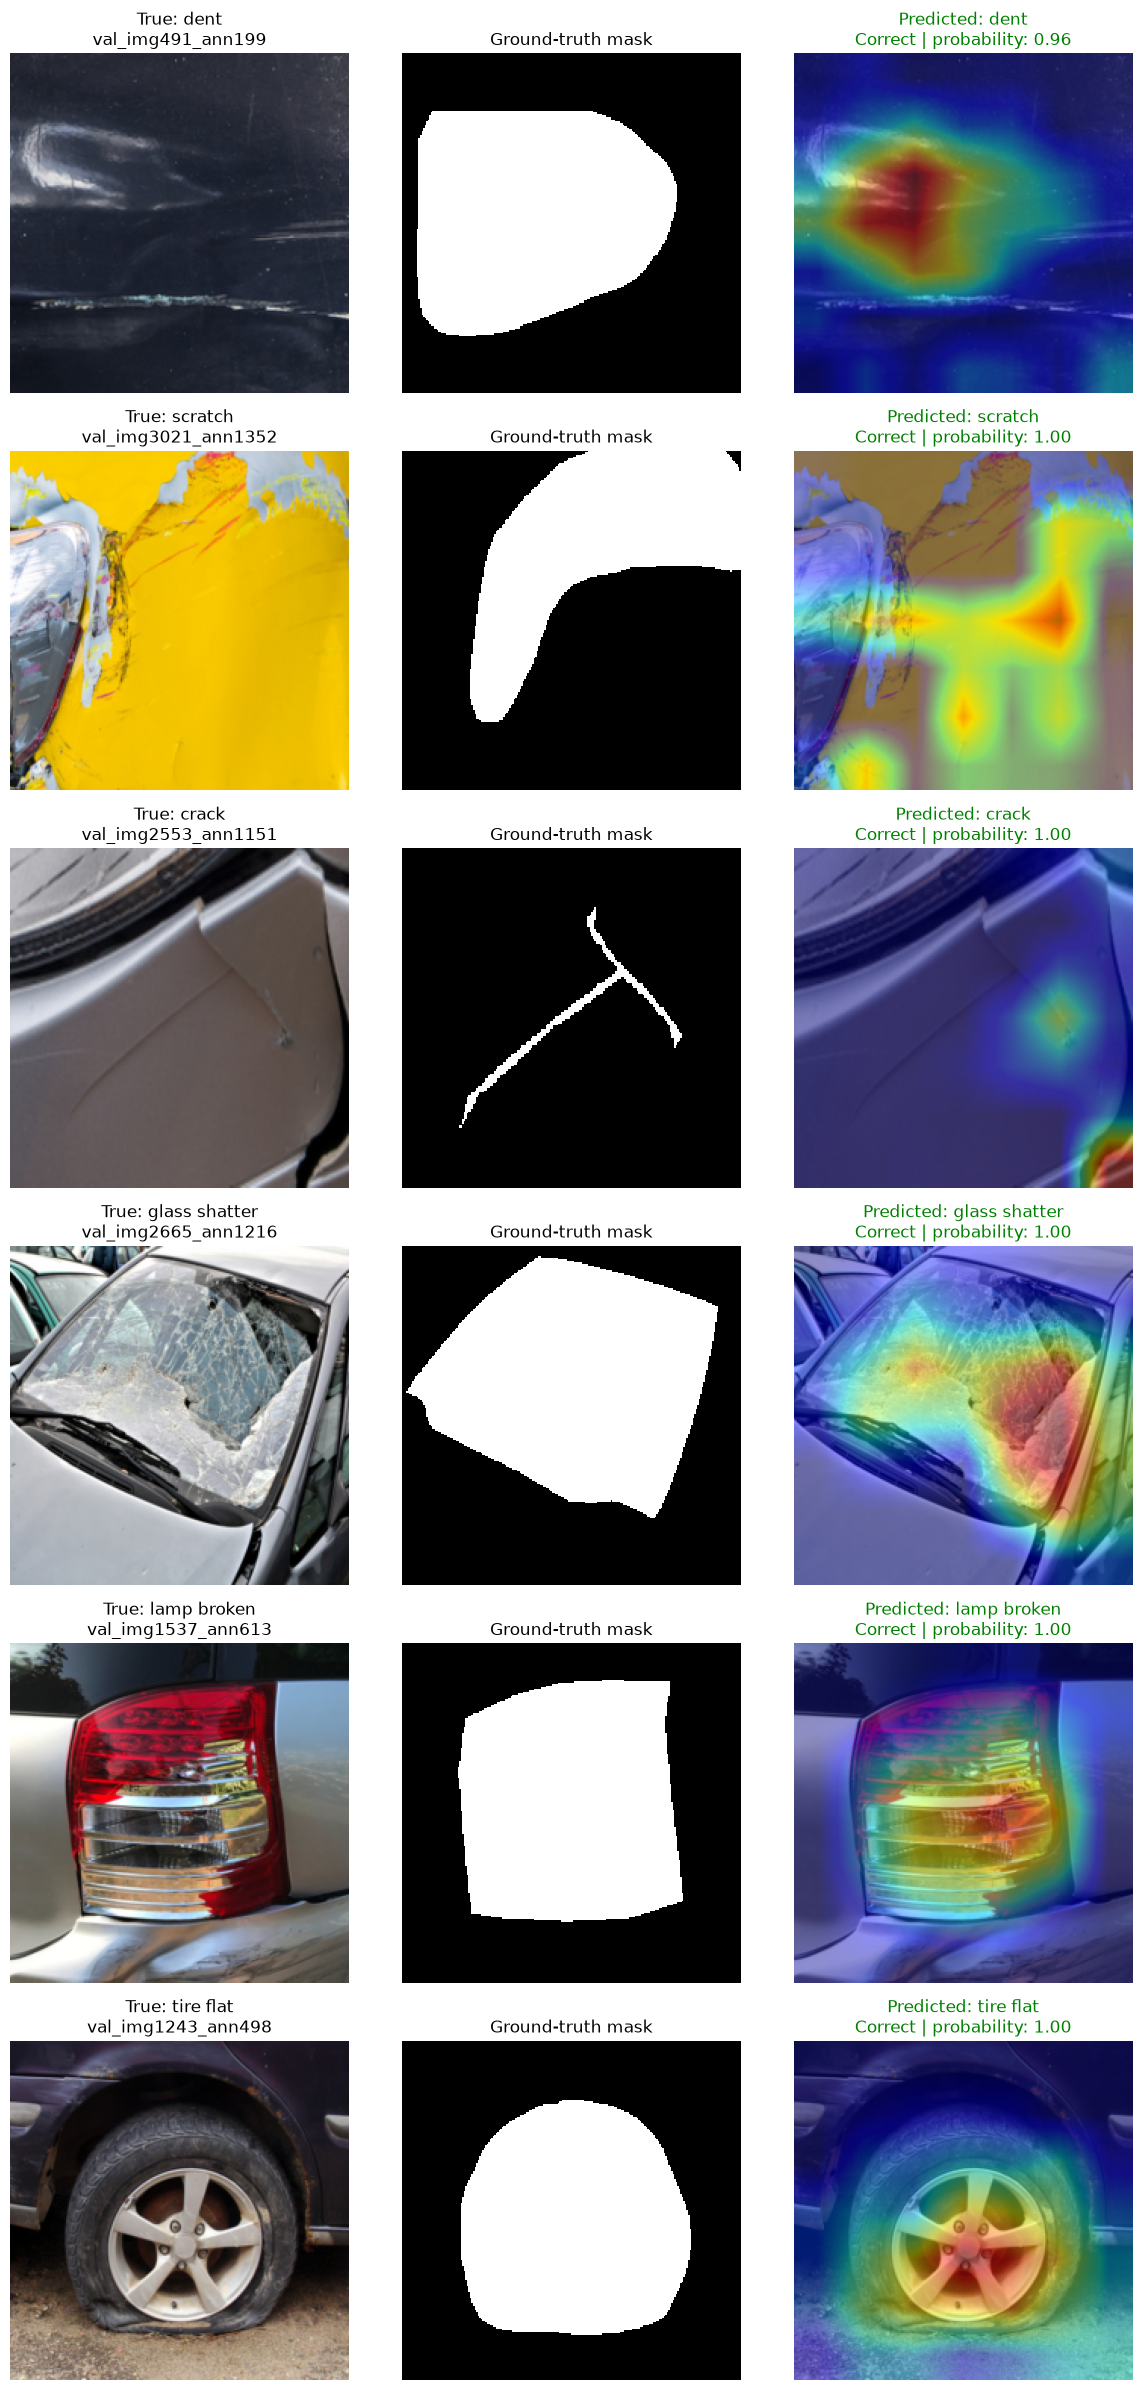

In [23]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    3,
    figsize=(12, 4 * len(CLASS_NAMES)),
    squeeze=False,
)

for row, category in enumerate(CLASS_NAMES):
    class_index = class_to_idx[category]

    # Positions correspond to val_dataset[index].
    candidates = np.flatnonzero(
        val_dataset.samples["class_index"].to_numpy()
        == class_index
    )

    if len(candidates) == 0:
        for ax in axes[row]:
            ax.axis("off")
        axes[row, 0].set_title(f"No samples: {category}")
        continue

    index = int(rng.choice(candidates))
    sample = val_dataset[index]

    result = generate_gradcam(
        model,
        sample["image"],
        device,
    )

    predicted_class = result["predicted_class"]
    predicted_label = CLASS_NAMES[predicted_class]
    correct = predicted_class == class_index

    # Reverse normalization for display.
    image = (
        sample["image"] * IMAGENET_STD + IMAGENET_MEAN
    ).permute(1, 2, 0).numpy().clip(0, 1)

    mask = sample["mask"].numpy()
    heatmap = result["heatmap"]

    # Column 1: input crop.
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"True: {category}\n{sample['sample_id']}"
    )

    # Column 2: ground-truth damage mask.
    axes[row, 1].imshow(
        mask,
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    axes[row, 1].set_title("Ground-truth mask")

    # Column 3: predicted-class Grad-CAM.
    axes[row, 2].imshow(image)

    if result["informative"]:
        axes[row, 2].imshow(
            heatmap,
            cmap="jet",
            alpha=0.45,
            vmin=0,
            vmax=1,
        )
        status = "Correct" if correct else "Incorrect"
    else:
        status = "Constant/zero heatmap"

    axes[row, 2].set_title(
        f"Predicted: {predicted_label}\n"
        f"{status} | probability: {result['probability']:.2f}",
        color="green" if correct else "red",
    )

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
THRESHOLDS = np.round(np.arange(0.1, 1.0, 0.1), 1)
validation_records = []

model.eval()

for index in range(len(val_dataset)):
    sample = val_dataset[index]

    result = generate_gradcam(
        model,
        sample["image"],
        device,
    )

    heatmap = result["heatmap"]
    mask = sample["mask"].numpy().astype(bool)

    if not mask.any():
        raise ValueError(
            f"Empty ground-truth mask: {sample['sample_id']}"
        )

    true_class = sample["label"].item()
    predicted_class = result["predicted_class"]

    for threshold in THRESHOLDS:
        predicted_mask = heatmap >= threshold

        intersection = np.logical_and(
            predicted_mask, mask
        ).sum()
        union = np.logical_or(predicted_mask, mask).sum()

        validation_records.append({
            "sample_id": sample["sample_id"],
            "image_id": sample["image_id"],
            "annotation_id": sample["annotation_id"],
            "true_category": CLASS_NAMES[true_class],
            "predicted_category": CLASS_NAMES[predicted_class],
            "correct": predicted_class == true_class,
            "probability": result["probability"],
            "informative": result["informative"],
            "threshold": float(threshold),
            "iou": float(intersection / union),
            "whole_crop_iou": float(mask.mean()),
        })

    if (index + 1) % 100 == 0 or index + 1 == len(val_dataset):
        print(
            f"Evaluated {index + 1}/{len(val_dataset)} crops",
            flush=True,
        )

validation_cam_df = pd.DataFrame(validation_records)

Evaluated 100/1744 crops
Evaluated 200/1744 crops
Evaluated 300/1744 crops
Evaluated 400/1744 crops
Evaluated 500/1744 crops
Evaluated 600/1744 crops
Evaluated 700/1744 crops
Evaluated 800/1744 crops
Evaluated 900/1744 crops
Evaluated 1000/1744 crops
Evaluated 1100/1744 crops
Evaluated 1200/1744 crops
Evaluated 1300/1744 crops
Evaluated 1400/1744 crops
Evaluated 1500/1744 crops
Evaluated 1600/1744 crops
Evaluated 1700/1744 crops
Evaluated 1744/1744 crops


,macro_class_iou,sample_mean_iou
threshold,,
0.1,0.400279,0.329432
0.2,0.394700,0.323319
0.3,0.370040,0.299670
0.4,0.326971,0.261501
0.5,0.268154,0.213089
0.6,0.200196,0.157913
0.7,0.130448,0.102047
0.8,0.068254,0.052811
0.9,0.022094,0.016674


Selected threshold: 0.1


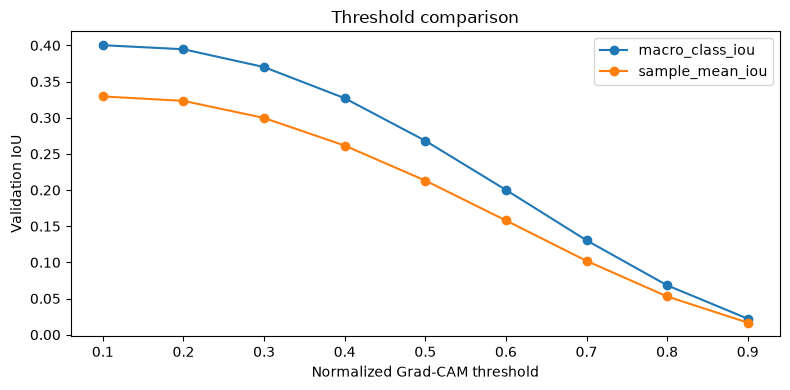

In [25]:
# Calculate mean IoU separately for each true class.
per_class_iou = (
    validation_cam_df
    .groupby(["threshold", "true_category"])["iou"]
    .mean()
    .unstack("true_category")
    .reindex(columns=CLASS_NAMES)
)

if per_class_iou.isna().any().any():
    raise ValueError(
        "At least one category is missing from validation results."
    )

threshold_summary = pd.DataFrame({
    "macro_class_iou": per_class_iou.mean(axis=1),
    "sample_mean_iou": (
        validation_cam_df.groupby("threshold")["iou"].mean()
    ),
}).sort_index()

# Ties select the smaller threshold because the index is ascending.
selected_threshold = float(
    threshold_summary["macro_class_iou"].idxmax()
)

display(threshold_summary)
print("Selected threshold:", selected_threshold)

ax = threshold_summary.plot(
    marker="o",
    figsize=(8, 4),
)
ax.set_xlabel("Normalized Grad-CAM threshold")
ax.set_ylabel("Validation IoU")
ax.set_title("Threshold comparison")
plt.tight_layout()
plt.show()

In [26]:
selected_results = validation_cam_df[
    validation_cam_df["threshold"] == selected_threshold
].copy()

selected_results["prediction_group"] = np.where(
    selected_results["correct"],
    "Correct",
    "Incorrect",
)

group_summary = (
    selected_results
    .groupby("prediction_group")
    .agg(
        samples=("sample_id", "count"),
        mean_iou=("iou", "mean"),
        median_iou=("iou", "median"),
        whole_crop_reference=("whole_crop_iou", "mean"),
        noninformative_maps=(
            "informative",
            lambda values: int((~values).sum()),
        ),
    )
)

display(group_summary)

# Check whether the group difference varies by damage category.
class_group_summary = (
    selected_results
    .groupby(["true_category", "prediction_group"])
    .agg(
        samples=("sample_id", "count"),
        mean_iou=("iou", "mean"),
    )
)

display(class_group_summary)

,samples,mean_iou,median_iou,whole_crop_reference,noninformative_maps
prediction_group,,,,,
Correct,1515,0.356008,0.347911,0.317417,0
Incorrect,229,0.153610,0.131596,0.255328,0


samples  mean_iou
true_category prediction_group                   
crack         Correct               144  0.220614
              Incorrect              33  0.034862
dent          Correct               418  0.367448
              Incorrect              83  0.191594
glass shatter Correct               133  0.575902
              Incorrect               2  0.149701
lamp broken   Correct               132  0.574026
              Incorrect               9  0.131026
scratch       Correct               628  0.271330
              Incorrect             100  0.165485
tire flat     Correct                60  0.520474
              Incorrect               2  0.048482

In [27]:
evaluation_dir = finetune_dir / "gradcam_validation"
evaluation_dir.mkdir(parents=True, exist_ok=True)

validation_cam_df.to_csv(
    evaluation_dir / "all_threshold_results.csv",
    index=False,
)
threshold_summary.to_csv(
    evaluation_dir / "threshold_summary.csv"
)
selected_results.to_csv(
    evaluation_dir / "selected_threshold_results.csv",
    index=False,
)

protocol = {
    "checkpoint": str(finetune_checkpoint_path.resolve()),
    "class_to_idx": dict(class_to_idx),
    "target_layer": "layer4[-1]",
    "target_score": "predicted_class_logit",
    "heatmap_normalization": "per_sample_min_max",
    "threshold": selected_threshold,
    "threshold_selection": "validation_macro_mean_iou_by_true_class",
    "threshold_candidates": THRESHOLDS.tolist(),
    "threshold_tie_break": "smallest_threshold",
    "reference_mask": "selected_annotation_mask",
    "constant_heatmap_policy": "empty_map_iou_zero_and_flag",
    "crop_rule": "bbox_fraction_per_side_round_outward_clip_to_image",
    "padding_fraction_per_side": CROP_PADDING,
    "resize": list(TARGET_SIZE),
    "augmentation_during_evaluation": False,
}

with (evaluation_dir / "evaluation_protocol.json").open("w") as f:
    json.dump(protocol, f, indent=2)

print("Saved results and protocol to:", evaluation_dir)

Saved results and protocol to: /Users/minkhant/Downloads/Grad-CAM_CarDD/runs/finetune_20260929_200641_528410/gradcam_validation
